<a href="https://colab.research.google.com/github/Iamnyatichi/CSCI_543_MachineLearning/blob/main/Detroit_MSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Install gurobi and set license
!pip install gurobipy
!pip install osmnx

import gurobipy as gp
from gurobipy import GRB
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt


# setting Gurobi license
options = {
"WLSACCESSID" :" 65fe3566-dc4d-4a4f-8f68-98b85cbcb55a",
"WLSSECRET" : "b10701d8-60f5-4f6b-b52a-f668e36642e1",
"LICENSEID" : 2867740,
}
env = gp.Env(params=wls_params)
# with gp.Env(params=options) as env, gp.Model(env=env) as model:
#     # Formulate problem
#     model.optimize()

print("All libraries imported✔✔")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.5 MB/s eta 0:00:00
All libraries imported✔✔


In [4]:
# CTPP data API and loading Detroit Flow data
BASE_URL = "https://ctppdata.transportation.org/api"

headers = {
 "x-api-key": "kpdu7qiuchefqgpkaj19iqaa",
 "Content-Type": "application/json",
 "Accept": "application/json"
}

In [5]:
#Loading CTPP data
group_id="B302103"

# Detroit MSA
detroit_msa_counties = [
    "087",  # Lapeer
    "093",  # Livingston
    "099",  # Macomb
    "125",  # Oakland
    "147",  # St. Clair
    "163"   # Wayne
]

for county in detroit_msa_counties:
  params={
        "get" : "b302103_e2,b302103_m2",  #"label": "Car, truck, or van -- Drove alone"
        "for" : "tract:*",
        "in" : f"state:26 county:{county}",
        "d-for" : "tract:*",
        "d-in" : f"state:26 county:{county}",
        "page" : 1,
        "size" : 5,
        "format" :"array"
    }

url=f"{BASE_URL}/data/2021"
response= requests.get(url, params=params, headers=headers)

print(response.status_code)
print(response.json())

200
{'size': 5, 'page': 1, 'total': 21407, 'data': [['destination_geoid', 'b302103_e2', 'origin_name', 'origin_geoid', 'destination_name', 'geoid', 'b302103_m2'], ['C3100US26163500100', '0', 'Census Tract 5001, Wayne County, Michigan', 'C1100US26163500100', 'Census Tract 5001, Wayne County, Michigan', 'C5400US2616350010026163500100', '+/-13'], ['C3100US26163503100', '0', 'Census Tract 5001, Wayne County, Michigan', 'C1100US26163500100', 'Census Tract 5031, Wayne County, Michigan', 'C5400US2616350010026163503100', '+/-13'], ['C3100US26163504400', '10', 'Census Tract 5001, Wayne County, Michigan', 'C1100US26163500100', 'Census Tract 5044, Wayne County, Michigan', 'C5400US2616350010026163504400', '+/-18'], ['C3100US26163507400', '20', 'Census Tract 5001, Wayne County, Michigan', 'C1100US26163500100', 'Census Tract 5074, Wayne County, Michigan', 'C5400US2616350010026163507400', '+/-40'], ['C3100US26163517200', '30', 'Census Tract 5001, Wayne County, Michigan', 'C1100US26163500100', 'Census

In [6]:
# Loading CTPP data
group_id = "B302103"

# Detroit MSA counties
detroit_msa_counties = [
    "087",  # Lapeer
    "093",  # Livingston
    "099",  # Macomb
    "125",  # Oakland
    "147",  # St. Clair
    "163"   # Wayne
]

all_data = []

#set origin and destination counties to account for cross-county commuting
# Origin county
for origin_county in detroit_msa_counties:

    # Destination county
    for destination_county in detroit_msa_counties:

        params = {
            "get": "b302103_e2,b302103_m2", #"label": "Car, truck, or van -- Drove alone"
            "for": "tract:*",
            "in": f"state:26 county:{origin_county}",
            "d-for": "tract:*",
            "d-in": f"state:26 county:{destination_county}",
            # "page": 1,
            # "size": 5000,
            "format": "array"
        }

        url = f"{BASE_URL}/data/2021"

        response = requests.get(url, params=params,headers=headers)
        print(
            f"{origin_county} -> {destination_county}: "
        )

        # save all returned data
        if response.status_code == 200:
            result = response.json()

            # Get the data array
            data = result["data"]

            # Save column names once
            if len(all_data) == 0:
                columns = data[0]

            # Add to the actual data file)
            all_data.extend(data[1:])


087 -> 087: 
087 -> 093: 
087 -> 099: 
087 -> 125: 
087 -> 147: 
087 -> 163: 
093 -> 087: 
093 -> 093: 
093 -> 099: 
093 -> 125: 
093 -> 147: 
093 -> 163: 
099 -> 087: 
099 -> 093: 
099 -> 099: 
099 -> 125: 
099 -> 147: 
099 -> 163: 
125 -> 087: 
125 -> 093: 
125 -> 099: 
125 -> 125: 
125 -> 147: 
125 -> 163: 
147 -> 087: 
147 -> 093: 
147 -> 099: 
147 -> 125: 
147 -> 147: 
147 -> 163: 
163 -> 087: 
163 -> 093: 
163 -> 099: 
163 -> 125: 
163 -> 147: 
163 -> 163: 


In [7]:
#save data as a Dataframe
detroit_flows= pd.DataFrame(all_data, columns=columns)
detroit_flows.head()

,destination_geoid,b302103_e2,origin_name,origin_geoid,destination_name,geoid,b302103_m2
0,C3100US26087330000,105,"Census Tract 3300, Lapeer County, Michigan",C1100US26087330000,"Census Tract 3300, Lapeer County, Michigan",C5400US2608733000026087330000,+/-105
1,C3100US26087330500,4,"Census Tract 3300, Lapeer County, Michigan",C1100US26087330000,"Census Tract 3305, Lapeer County, Michigan",C5400US2608733000026087330500,+/-1
2,C3100US26087332000,4,"Census Tract 3300, Lapeer County, Michigan",C1100US26087330000,"Census Tract 3320, Lapeer County, Michigan",C5400US2608733000026087332000,+/-2
3,C3100US26087332500,25,"Census Tract 3300, Lapeer County, Michigan",C1100US26087330000,"Census Tract 3325, Lapeer County, Michigan",C5400US2608733000026087332500,+/-18
4,C3100US26087333000,10,"Census Tract 3300, Lapeer County, Michigan",C1100US26087330000,"Census Tract 3330, Lapeer County, Michigan",C5400US2608733000026087333000,+/-13


In [8]:
#Cleaning and Preparing the DataFrame
detroit_flows.shape

(78783, 7)

In [9]:
detroit_flows["origin_geoid"].head(10)

,origin_geoid
0,C1100US26087330000
1,C1100US26087330000
2,C1100US26087330000
3,C1100US26087330000
4,C1100US26087330000
5,C1100US26087330000
6,C1100US26087330000
7,C1100US26087330000
8,C1100US26087330000
9,C1100US26087330000


In [10]:
detroit_flows['destination_geoid'].head(10)

,destination_geoid
0,C3100US26087330000
1,C3100US26087330500
2,C3100US26087332000
3,C3100US26087332500
4,C3100US26087333000
5,C3100US26087333500
6,C3100US26087334000
7,C3100US26087336000
8,C3100US26087337000
9,C3100US26087337500


In [11]:
#clean origin and destination data
detroit_flows["origin_tract"]=detroit_flows['origin_geoid'].str.replace("C1100US", "", regex=False)
detroit_flows['destination_tract']=detroit_flows['destination_geoid'].str.replace("C3100US", "", regex=False)

#commuter flow to workers
detroit_flows["workers"]=pd.to_numeric(detroit_flows['b302103_e2'], errors="coerce")

detroit_flows=detroit_flows[["origin_tract", "destination_tract","workers","origin_name","destination_name"]].copy()
detroit_flows.head()

,origin_tract,destination_tract,workers,origin_name,destination_name
0,26087330000,26087330000,105,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3300, Lapeer County, Michigan"
1,26087330000,26087330500,4,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3305, Lapeer County, Michigan"
2,26087330000,26087332000,4,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3320, Lapeer County, Michigan"
3,26087330000,26087332500,25,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3325, Lapeer County, Michigan"
4,26087330000,26087333000,10,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3330, Lapeer County, Michigan"


In [12]:
print(detroit_flows.shape)
print(detroit_flows.dtypes)
print(detroit_flows['workers'].sum())

(78783, 5)
origin_tract         object
destination_tract    object
workers               int64
origin_name          object
destination_name     object
dtype: object
1325897


In [13]:
#Calculate Oi and Dj
origin_totals=(
    detroit_flows.groupby("origin_tract")["workers"].sum().reset_index(name="O-i")
)
origin_totals.head() #total workers who reside in each tract

,origin_tract,O-i
0,26087330000,1027
1,26087330500,542
2,26087331000,228
3,26087331500,540
4,26087332000,1523


In [14]:
#total workers who work in each tract Di
destination_totals=(
    detroit_flows.groupby("destination_tract")["workers"].sum().reset_index(name="D_j")
)
destination_totals.head()

,destination_tract,D_j
0,26087330000,407
1,26087330500,202
2,26087331000,40
3,26087331500,67
4,26087332000,171


In [15]:
#Cheecking if workers and jobs are equal
print("Total workers:", origin_totals['O-i'].sum())
print("Total Jobs:", destination_totals['D_j'].sum())

#checking if tracts are identical
print("No. of origin tracts:", origin_totals['origin_tract'].nunique())
print("No. of destination tracts:", destination_totals['destination_tract'].nunique())

origin_set = set(origin_totals["origin_tract"])
destination_set = set(destination_totals["destination_tract"])

print("Origins not in destinations:", len(origin_set - destination_set))
print("Destinations not in origins:", len(destination_set - origin_set))


Total workers: 1325897
Total Jobs: 1325897
No. of origin tracts: 1300
No. of destination tracts: 1351
Origins not in destinations: 0
Destinations not in origins: 51


In [16]:
#The 51 destinations
destination_only = destination_set - origin_set

destination_only_df = destination_totals[
    destination_totals["destination_tract"].isin(destination_only)
].copy()

destination_only_df.sort_values(
    "D_j",
    ascending=False
).head(5)

,destination_tract,D_j
675,26125981500,21888
322,26099982001,9629
1327,26163983800,8489
1329,26163983902,8218
674,26125981400,7594


In [17]:
# workers
print(
    "Jobs in destination-only tracts:",
    destination_only_df["D_j"].sum()
)
print(
    "Share of all jobs:",
    destination_only_df["D_j"].sum()
    / destination_totals["D_j"].sum() * 100
)

Jobs in destination-only tracts: 104123
Share of all jobs: 7.853023274055225


In [18]:
#Travel cost matrix start here
#Msa tracts, all
# Create complete set of Detroit MSA tracts
all_tracts = sorted(
    set(detroit_flows["origin_tract"]) |
    set(detroit_flows["destination_tract"])
)

print("Total tracts:", len(all_tracts))

Total tracts: 1351


In [19]:
#getting census geographic locations from Tiger
tract_url=("https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_26_tract.zip")
tracts=gpd.read_file(tract_url)
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,26,163,536800,26163536800,1400000US26163536800,5368,Census Tract 5368,G5020,S,634684,0,+42.4064903,-083.1658850,"POLYGON ((-83.17 42.41442, -83.16949 42.41399,..."
1,26,163,536900,26163536900,1400000US26163536900,5369,Census Tract 5369,G5020,S,974586,0,+42.4129308,-083.1776478,"POLYGON ((-83.18518 42.41652, -83.18468 42.416..."
2,26,163,537000,26163537000,1400000US26163537000,5370,Census Tract 5370,G5020,S,1006724,0,+42.4057432,-083.1771291,"POLYGON ((-83.18485 42.4092, -83.18375 42.4092..."
3,26,163,537100,26163537100,1400000US26163537100,5371,Census Tract 5371,G5020,S,1140778,0,+42.3979605,-083.1764870,"POLYGON ((-83.18453 42.40194, -83.18341 42.401..."
4,26,163,537200,26163537200,1400000US26163537200,5372,Census Tract 5372,G5020,S,1160085,0,+42.3883037,-083.1758674,"POLYGON ((-83.18311 42.38668, -83.18307 42.387..."


In [20]:
#Detroit_MSA tracts
detroit_tracts=tracts[tracts['GEOID'].isin(all_tracts)].copy()
print(detroit_tracts.shape)


(1351, 14)


In [21]:
#Geographics
# Check current CRS
print(detroit_tracts.crs)

# Projected CRS for Detroit
detroit_tracts_proj = detroit_tracts.to_crs(epsg=26917)  #NAD83 17N, meters

# Create a geometry point inside each tract
detroit_tracts_proj["geometry_point"] = (
    detroit_tracts_proj.geometry.representative_point()   #to guarantee the point lies within the tract.
)

#create a GeoDataFrame
tract_points = gpd.GeoDataFrame(
    detroit_tracts_proj[["GEOID"]].copy(),
    geometry=detroit_tracts_proj["geometry_point"],
    crs=detroit_tracts_proj.crs
)

tract_points.head()

EPSG:4269


,GEOID,geometry
0,26163536800,POINT (321689.465 4697421.207)
1,26163536900,POINT (320833.659 4697909.58)
2,26163537000,POINT (320839.635 4697220.35)
3,26163537100,POINT (320848.596 4696198.405)
4,26163537200,POINT (320890.915 4695086.394)


In [22]:
#converting the geometry point to lat and lon
tract_points = tract_points.to_crs(epsg=4326) #WGS 84 allow compatibility with Osmnx

tract_points["longitude"] = tract_points.geometry.x
tract_points["latitude"] = tract_points.geometry.y

tract_points.head()


,GEOID,geometry,longitude,latitude
0,26163536800,POINT (-83.16692 42.40862),-83.166922,42.408621
1,26163536900,POINT (-83.17747 42.41282),-83.177467,42.412820
2,26163537000,POINT (-83.17718 42.40662),-83.177180,42.406618
3,26163537100,POINT (-83.17675 42.39742),-83.176753,42.397423
4,26163537200,POINT (-83.17589 42.38743),-83.175893,42.387425


In [23]:
print(tract_points.shape)
print(tract_points.crs)

(1351, 4)
EPSG:4326


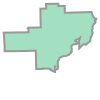

In [24]:
#Import road network data using Osmnx
detroit_MSA_boundary= detroit_tracts.to_crs(4326).geometry.union_all()
detroit_MSA_boundary

In [25]:
#drivable road network
# import osmnx as ox
detroit_msa_roads=ox.graph_from_polygon(
    detroit_MSA_boundary,
    network_type="drive",
    simplify=True
)

In [26]:
print(detroit_msa_roads)
print("Nodes:", len(detroit_msa_roads.nodes))
print("Edges:", len(detroit_msa_roads.edges))
print(detroit_msa_roads.graph['crs'])

MultiDiGraph with 155963 nodes and 410457 edges
Nodes: 155963
Edges: 410457
epsg:4326


In [27]:
#Assign the representative points to a nearest rode node.
tract_points["network_node"]= ox.distance.nearest_nodes(
    detroit_msa_roads,
    X= tract_points["longitude"],
    Y=tract_points['latitude']
)
tract_points[["GEOID","longitude","latitude",'network_node']].head()

,GEOID,longitude,latitude,network_node
0,26163536800,-83.166922,42.408621,62606789
1,26163536900,-83.177467,42.412820,62737173
2,26163537000,-83.177180,42.406618,62737164
3,26163537100,-83.176753,42.397423,62632259
4,26163537200,-83.175893,42.387425,62891713


In [28]:
print("Total tracts:", len(tract_points))

print("Tracts with network node:",
    tract_points["network_node"].notna().sum())
print("Missing network nodes:",
    tract_points["network_node"].isna().sum())
print("Unique network nodes:",
    tract_points["network_node"].nunique())

Total tracts: 1351
Tracts with network node: 1351
Missing network nodes: 0
Unique network nodes: 1351


In [29]:
#travel times
detroit_msa_roads=ox.routing.add_edge_speeds(detroit_msa_roads) # to add speed
#travel times
detroit_msa_roads=ox.routing.add_edge_travel_times(detroit_msa_roads)

edges=ox.graph_to_gdfs(detroit_msa_roads,nodes=False)
edges.head()

osmid    highway  \
u        v           key                                                   
27010810 62930610    0                                8701608  secondary   
         62254441    0    [1449255138, 256914251, 1449255139]   tertiary   
         11388862212 0                              501997962      trunk   
27010812 62374553    0                               42372738      trunk   
         27010815    0                               42372876      trunk   

                              lanes maxspeed                name  oneway  \
u        v           key                                                   
27010810 62930610    0            4   35 mph     Beech Daly Road   False   
         62254441    0    [5, 2, 4]   35 mph          Beech Road   False   
         11388862212 0            4   45 mph    West 8 Mile Road    True   
27010812 62374553    0            4   45 mph  Grand River Avenue    True   
         27010815    0            4   45 mph    West 8 Mile Road    True   

                         reversed      length  \
u        v           key                        
27010810 62930610    0       True   38.206693   
         62254441    0      False  257.663456   
         11388862212 0      False  105.862441   
27010812 62374553    0      False   56.521161   
         27010815    0      False   90.008303   

                                                                   geometry  \
u        v           key                                                      
27010810 62930610    0    LINESTRING (-83.29738 42.44265, -83.29742 42.4...   
         62254441    0    LINESTRING (-83.29738 42.44265, -83.29737 42.4...   
         11388862212 0    LINESTRING (-83.29738 42.44265, -83.29758 42.4...   
27010812 62374553    0    LINESTRING (-83.32021 42.44181, -83.32082 42.4...   
         27010815    0    LINESTRING (-83.32021 42.44181, -83.31911 42.4...   

                          speed_kph  travel_time    ref junction tunnel  \
u        v           key                                                  
27010810 62930610    0      56.3269     2.441890    NaN      NaN    NaN   
         62254441    0      56.3269    16.467948    NaN      NaN    NaN   
         11388862212 0      72.4203     5.262403  M 102      NaN    NaN   
27010812 62374553    0      72.4203     2.809657    M 5      NaN    NaN   
         27010815    0      72.4203     4.474296  M 102      NaN    NaN   

                         bridge width access landuse  
u        v           key                              
27010810 62930610    0      NaN   NaN    NaN     NaN  
         62254441    0      NaN   NaN    NaN     NaN  
         11388862212 0      NaN   NaN    NaN     NaN  
27010812 62374553    0      NaN   NaN    NaN     NaN  
         27010815    0      NaN   NaN    NaN     NaN

In [30]:
edges[["length","speed_kph","travel_time"]].head()

length  speed_kph  travel_time
u        v           key                                    
27010810 62930610    0     38.206693    56.3269     2.441890
         62254441    0    257.663456    56.3269    16.467948
         11388862212 0    105.862441    72.4203     5.262403
27010812 62374553    0     56.521161    72.4203     2.809657
         27010815    0     90.008303    72.4203     4.474296

In [31]:
print(edges["travel_time"].describe())
print("Missing travel times:",edges["travel_time"].isna().sum())

count    410457.000000
mean         15.480823
std          19.330552
min           0.017239
25%           6.040559
50%           9.342994
75%          18.465587
max         437.335356
Name: travel_time, dtype: float64
Missing travel times: 0


In [32]:
#GEOID to road network node
tract_to_node=dict(
    zip(
        tract_points['GEOID'],
        tract_points['network_node']
    )
)
#GEOID tracts
origin_tracts=origin_totals['origin_tract'].tolist()
destination_tracts=destination_totals['destination_tract'].tolist()

#network nodes
origin_nodes=[tract_to_node[tract] for tract in origin_tracts]
destination_nodes=[tract_to_node[tract] for tract in destination_tracts]
print("Origins:", len(origin_nodes))
print("Destinations:", len(destination_nodes))


Origins: 1300
Destinations: 1351


In [33]:
# for one origin tract
test_origin= origin_tracts[0]
test_node=tract_to_node[test_origin]  #to get it's network node

#travel tim, shortest
travel_times= nx.single_source_dijkstra_path_length(
    detroit_msa_roads,
    test_node,
    weight="travel_time"
)
print("Origin tract:", test_origin)
print("Network node:", test_node)
print("Reachable network nodes:", len(travel_times))

Origin tract: 26087330000
Network node: 184902625
Reachable network nodes: 155821


In [34]:
#for all 1351 destinations
test_costs = []
for destination in destination_tracts:
    destination_node = tract_to_node[destination]
    time_seconds = travel_times.get(
        destination_node,
        float("inf")
    )

    test_costs.append([
        test_origin,
        destination,
        time_seconds
    ])
#store as a Dataframe
test_costs = pd.DataFrame(
    test_costs,
    columns=[
        "origin_tract",
        "destination_tract",
        "travel_time_sec"
    ]
)

# Convert seconds to minutes
test_costs["travel_time_min"] = (test_costs["travel_time_sec"] / 60)
test_costs.head()

,origin_tract,destination_tract,travel_time_sec,travel_time_min
0,26087330000,26087330000,0.000000,0.000000
1,26087330000,26087330500,1530.132621,25.502210
2,26087330000,26087331000,2213.320492,36.888675
3,26087330000,26087331500,1937.874257,32.297904
4,26087330000,26087332000,1509.620608,25.160343


In [35]:
#checking for unreachable destinations
print("Number of destinations:", len(test_costs))
print("Unreachable destinations:",(test_costs["travel_time_sec"] == float("inf")).sum())
print(test_costs["travel_time_min"].describe())

Number of destinations: 1351
Unreachable destinations: 1
count    1351.000000
mean             inf
std              NaN
min         0.000000
25%        59.636655
50%        70.280460
75%        81.256832
max              inf
Name: travel_time_min, dtype: float64


In [36]:
unreachable = test_costs[test_costs["travel_time_sec"] == float("inf")]
unreachable

,origin_tract,destination_tract,travel_time_sec,travel_time_min
78,26087330000,26093744200,inf,inf


In [37]:
#network node
for tract in unreachable["destination_tract"]:
    print("Network node:", tract_to_node[tract])

Network node: 8405391629


In [38]:
unreachable_tract = unreachable.iloc[0]["destination_tract"]
unreachable_node = tract_to_node[unreachable_tract]
print("Undirected path exists:",
    nx.has_path(
        detroit_msa_roads.to_undirected(),
        test_node,
        unreachable_node
    ))
print("Directed path exists:",
    nx.has_path(
        detroit_msa_roads,
        test_node,
        unreachable_node
    ))
#tract is not geographically disconnected, it physically connects, but no valid directed route
#for osm

Undirected path exists: True
Directed path exists: False


In [39]:
print("Unreachable tract:", unreachable_tract)
print("Unreachable node:", unreachable_node)

#  tract information
detroit_tracts[
    detroit_tracts["GEOID"] == unreachable_tract
][["GEOID", "NAMELSAD", "COUNTYFP"]]

Unreachable tract: 26093744200
Unreachable node: 8405391629


,GEOID,NAMELSAD,COUNTYFP
860,26093744200,Census Tract 7442,093


In [40]:
detroit_msa_roads.nodes[unreachable_node]

{'y': 42.4880005, 'x': -83.7247063, 'street_count': 3}

In [41]:
print("Incoming edges:",detroit_msa_roads.in_degree(unreachable_node))
print("Outgoing edges:",detroit_msa_roads.out_degree(unreachable_node))
print("Destination -> Origin path:",nx.has_path(detroit_msa_roads,unreachable_node,test_node))

Incoming edges: 3
Outgoing edges: 3
Destination -> Origin path: True


In [42]:
# Find the largest strongly connected component
largest_scc = max(nx.strongly_connected_components(detroit_msa_roads),key=len)
print("Nodes in road network:", len(detroit_msa_roads.nodes))
print("Nodes in largest SCC:", len(largest_scc))

tract_points["in_largest_scc"] = (tract_points["network_node"].isin(largest_scc))
print("Tracts inside largest SCC:",tract_points["in_largest_scc"].sum())
print("Tracts outside largest SCC:",(~tract_points["in_largest_scc"]).sum())
tract_points.loc[ ~tract_points["in_largest_scc"], ["GEOID", "network_node"]]

Nodes in road network: 155963
Nodes in largest SCC: 155689
Tracts inside largest SCC: 1348
Tracts outside largest SCC: 3


,GEOID,network_node
774,26093740900,7400598415
860,26093744200,8405391629
2955,26163985100,62556336


In [43]:
#re-snap the 3 outside
# road network for the largest
detroit_scc = detroit_msa_roads.subgraph(largest_scc).copy()
print("Nodes in SCC network:", len(detroit_scc.nodes))

Nodes in SCC network: 155689


In [44]:
#re-snap
tract_points["network_node_scc"] = ox.distance.nearest_nodes(
    detroit_scc,
    X=tract_points["longitude"],
    Y=tract_points["latitude"]
)

In [45]:
tract_points["node_changed"] = (
    tract_points["network_node"]
    != tract_points["network_node_scc"])
print("Tracts snap node changed:",
    tract_points["node_changed"].sum())

tract_points.loc[tract_points["node_changed"],["GEOID","network_node", "network_node_scc"]]

Tracts snap node changed: 3


,GEOID,network_node,network_node_scc
774,26093740900,7400598415,2691467073
860,26093744200,8405391629,27585975
2955,26163985100,62556336,62556327


In [46]:
#replace them
tract_points["network_node"] = (tract_points["network_node_scc"])
tract_to_node = dict(zip(
        tract_points["GEOID"],
        tract_points["network_node"]
    ))

In [47]:
#repeating code for origin-destination using the updated
origin_tracts = origin_totals["origin_tract"].tolist()
destination_tracts = destination_totals["destination_tract"].tolist()

# Updated network nodes
origin_nodes = [tract_to_node[tract]for tract in origin_tracts]
destination_nodes = [tract_to_node[tract]for tract in destination_tracts]

print("Origins:", len(origin_nodes))
print("Destinations:", len(destination_nodes))

Origins: 1300
Destinations: 1351


In [48]:
# Test first origin
test_origin = origin_tracts[0]
test_node = tract_to_node[test_origin]
travel_times = nx.single_source_dijkstra_path_length(
    detroit_scc,
    test_node,
    weight="travel_time"
)
unreachable_count = 0
for destination in destination_tracts:
    destination_node = tract_to_node[destination]
    if destination_node not in travel_times:
        unreachable_count += 1

print("Unreachable destinations:", unreachable_count)
print("Unique origin nodes:", len(set(origin_nodes)))
print("Unique destination nodes:", len(set(destination_nodes)))

Unreachable destinations: 0
Unique origin nodes: 1300
Unique destination nodes: 1351


In [49]:
# Store all OD travel costs and use Dijkstra
cost_records = []
for i, origin in enumerate(origin_tracts):
    origin_node = tract_to_node[origin]

    # Shortest travel time to all network nodes
    travel_times = nx.single_source_dijkstra_path_length(
        detroit_scc,
        origin_node,
        weight="travel_time"
    )

    # travel time to each destination tract
    for destination in destination_tracts:
        destination_node = tract_to_node[destination]
        travel_time_sec = travel_times[destination_node]
        cost_records.append([
            origin,
            destination,
            travel_time_sec])

    # completion
    if (i + 1) % 100 == 0:
        print(
            f"Completed {i + 1} of {len(origin_tracts)} origins"
        )

Completed 100 of 1300 origins
Completed 200 of 1300 origins
Completed 300 of 1300 origins
Completed 400 of 1300 origins
Completed 500 of 1300 origins
Completed 600 of 1300 origins
Completed 700 of 1300 origins
Completed 800 of 1300 origins
Completed 900 of 1300 origins
Completed 1000 of 1300 origins
Completed 1100 of 1300 origins
Completed 1200 of 1300 origins
Completed 1300 of 1300 origins


In [54]:
cost_records.to_csv(
    "detroit_travel_time_cost_matrix.csv",
    index=False
)

In [50]:
#save data as a Dataframe
cost_matrix = pd.DataFrame(
    cost_records,
    columns=[
        "origin_tract",
        "destination_tract",
        "travel_time_sec"
        ])
# seconds to minutes
cost_matrix["travel_time_min"] = (cost_matrix["travel_time_sec"] / 60)
cost_matrix.head()

,origin_tract,destination_tract,travel_time_sec,travel_time_min
0,26087330000,26087330000,0.000000,0.000000
1,26087330000,26087330500,1530.132621,25.502210
2,26087330000,26087331000,2213.320492,36.888675
3,26087330000,26087331500,1937.874257,32.297904
4,26087330000,26087332000,1509.620608,25.160343


In [51]:
print("OD pairs:", len(cost_matrix))

print( "Missing travel times:",
    cost_matrix["travel_time_min"].isna().sum()
)
# import numpy as np
print("Infinite travel times:",
    np.isinf(cost_matrix["travel_time_min"]).sum()
)

OD pairs: 1756300
Missing travel times: 0
Infinite travel times: 0


In [55]:
#Intrazonal commute
# Identify observed intrazonal commuting flows
intrazonal_flows = detroit_flows[
    detroit_flows["origin_tract"] ==
    detroit_flows["destination_tract"]
].copy()

print("Intrazonal OD pairs:", len(intrazonal_flows))

print("Intrazonal workers:",intrazonal_flows["workers"].sum())
print("Percent of workers intrazonal:", intrazonal_flows["workers"].sum() / detroit_flows["workers"].sum() * 100)

#check the cost matrix
intrazonal_costs = cost_matrix[
    cost_matrix["origin_tract"] ==
    cost_matrix["destination_tract"]
]

print("Intrazonal cost pairs:", len(intrazonal_costs))
print(intrazonal_costs["travel_time_min"].describe())

Intrazonal OD pairs: 1278
Intrazonal workers: 47352
Percent of workers intrazonal: 3.571318134063204
Intrazonal cost pairs: 1300
count    1300.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: travel_time_min, dtype: float64


In [56]:
# Estimating travel time for intrazonal
cost_matrix_adjusted = cost_matrix.copy()

# Find non-intrazonal pairs
interzonal = cost_matrix_adjusted[
    cost_matrix_adjusted["origin_tract"] !=
    cost_matrix_adjusted["destination_tract"]
]

# Find minimum interzonal travel time for each origin tract
nearest_interzonal = (interzonal
    .groupby("origin_tract")["travel_time_min"]
    .min()
    .reset_index(name="nearest_interzonal_min")
)

# Estimated intrazonal travel time = 1/2 nearest interzonal time
nearest_interzonal["intrazonal_time_min"] = (
    0.5 * nearest_interzonal["nearest_interzonal_min"])

nearest_interzonal.head()

,origin_tract,nearest_interzonal_min,intrazonal_time_min
0,26087330000,14.312705,7.156353
1,26087330500,16.396858,8.198429
2,26087331000,10.935917,5.467959
3,26087331500,10.730864,5.365432
4,26087332000,10.730864,5.365432


In [57]:
print(nearest_interzonal["intrazonal_time_min"].describe())

count    1300.000000
mean        1.330658
std         0.978565
min         0.298088
25%         0.756846
50%         1.040168
75%         1.490482
max         8.198429
Name: intrazonal_time_min, dtype: float64


In [58]:
nearest_interzonal.sort_values("intrazonal_time_min").head(10)

,origin_tract,nearest_interzonal_min,intrazonal_time_min
813,26163520300,0.596176,0.298088
814,26163520400,0.596176,0.298088
722,26163500700,0.686506,0.343253
848,26163526400,0.698854,0.349427
1166,26163574000,0.719150,0.359575
1167,26163574100,0.719150,0.359575
855,26163530500,0.753366,0.376683
862,26163531501,0.753366,0.376683
841,26163525700,0.754008,0.377004
724,26163500900,0.761969,0.380984


In [59]:
#replace to the original file with zero travel times
intrazonal_time_map = dict(
    zip(
        nearest_interzonal["origin_tract"],
        nearest_interzonal["intrazonal_time_min"]
    ))

# Identify intrazonal cells
mask = (
    cost_matrix_adjusted["origin_tract"] ==
    cost_matrix_adjusted["destination_tract"]
)

# Replace zero intrazonal costs
cost_matrix_adjusted.loc[
    mask,
    "travel_time_min"
] = (
    cost_matrix_adjusted.loc[
        mask,
        "origin_tract"
    ].map(intrazonal_time_map)
)

In [60]:
intrazonal_check = cost_matrix_adjusted[
    cost_matrix_adjusted["origin_tract"] ==
    cost_matrix_adjusted["destination_tract"]
]
print(intrazonal_check["travel_time_min"].describe())
print("Zero intrazonal costs:",
      (intrazonal_check["travel_time_min"] == 0).sum())
print("Missing intrazonal costs:",
    intrazonal_check["travel_time_min"].isna().sum())

count    1300.000000
mean        1.330658
std         0.978565
min         0.298088
25%         0.756846
50%         1.040168
75%         1.490482
max         8.198429
Name: travel_time_min, dtype: float64
Zero intrazonal costs: 0
Missing intrazonal costs: 0


In [62]:
#observed commute
observed_commute = detroit_flows.merge(
    cost_matrix_adjusted[
        [
            "origin_tract",
            "destination_tract",
            "travel_time_min"
        ]
    ],
    on=["origin_tract", "destination_tract"],
    how="left"
)
print("Observed OD flows:", len(observed_commute))
print("Workers:", observed_commute["workers"].sum())
print("Missing travel times:", observed_commute["travel_time_min"].isna().sum())
observed_commute.head()

Observed OD flows: 78783
Workers: 1325897
Missing travel times: 0


,origin_tract,destination_tract,workers,origin_name,destination_name,travel_time_min
0,26087330000,26087330000,105,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3300, Lapeer County, Michigan",7.156353
1,26087330000,26087330500,4,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3305, Lapeer County, Michigan",25.502210
2,26087330000,26087332000,4,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3320, Lapeer County, Michigan",25.160343
3,26087330000,26087332500,25,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3325, Lapeer County, Michigan",14.312705
4,26087330000,26087333000,10,"Census Tract 3300, Lapeer County, Michigan","Census Tract 3330, Lapeer County, Michigan",19.650948


In [64]:
#Observed commute
observed_commute["worker_minutes"] = (observed_commute["workers"] *
    observed_commute["travel_time_min"]
)
C_obs = (observed_commute["worker_minutes"].sum() / observed_commute["workers"].sum())
print("Observed average commute time:", C_obs, "minutes")

Observed average commute time: 17.011010513640798 minutes


In [68]:
# Theoretical minimum using the transportation problem
#checking if the transportation equation is balanced
print("Origin tracts:", len(origin_totals))
print("Destination tracts:", len(destination_totals))

print("Total workers at origins:", origin_totals["O-i"].sum())
print("Total jobs at destinations:", destination_totals["D_j"].sum())
print("Difference:",origin_totals["O-i"].sum()- destination_totals["D_j"].sum())

Origin tracts: 1300
Destination tracts: 1351
Total workers at origins: 1325897
Total jobs at destinations: 1325897
Difference: 0


In [69]:
# Origin workers:  number of workers
O = dict(zip(
        origin_totals["origin_tract"],
        origin_totals["O-i"]
    ))

# Destination jobs:  number of jobs
D = dict(zip(
        destination_totals["destination_tract"],
        destination_totals["D_j"]
    ))

# Travel-time costs: origin, destination
C = dict( zip( zip(
            cost_matrix_adjusted["origin_tract"],
            cost_matrix_adjusted["destination_tract"]
        ),
        cost_matrix_adjusted["travel_time_min"] ))

print("Origins:", len(O))
print("Destinations:", len(D))
print("OD costs:", len(C))

print("Origin workers:", sum(O.values()))
print("Destination jobs:", sum(D.values()))

Origins: 1300
Destinations: 1351
OD costs: 1756300
Origin workers: 1325897
Destination jobs: 1325897


In [81]:

# setting Gurobi license
# options = {
# "WLSACCESSID" :" 65fe3566-dc4d-4a4f-8f68-98b85cbcb55a",
# "WLSSECRET" : "b10701d8-60f5-4f6b-b52a-f668e36642e1",
# "LICENSEID" : 2867740,
# }
# env = gp.Env(params=options)


# print("All libraries imported✔✔")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2867740
Academic license 2867740 - for non-commercial use only - registered to th___@und.edu
All libraries imported✔✔


In [88]:
#Gurobi model
model=gp.Model("Detroit_Min_Commute",
               env=env)

#number of workers assigned
x = model.addVars(
    C.keys(),
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="x"
)
model.update()
print("Decision variables:", model.NumVars)

Decision variables: 1756300


In [89]:
#Adding origin
origin_constraints = model.addConstrs(
    (gp.quicksum(
            x[i, j] for j in D.keys()
        ) == O[i]
        for i in O.keys()
    ),
    name="origin"
)
model.update()
print("Constraints:", model.NumConstrs)

Constraints: 1300


In [90]:
#Adding destination
destination_constraints = model.addConstrs(
    (gp.quicksum(
            x[i, j] for i in O.keys()
        ) == D[j]
        for j in D.keys()
    ),
    name="destination"
)
model.update()
print("Total constraints:", model.NumConstrs)

Total constraints: 2651


In [91]:
#Let gurobi minimize
model.setObjective(
    gp.quicksum(
        C[i, j] * x[i, j]
        for i, j in C.keys()
    ),
    GRB.MINIMIZE
)
model.update()
print("Variables:", model.NumVars)
print("Constraints:", model.NumConstrs)
print("Objective sense:", model.ModelSense)  #means minimization

Variables: 1756300
Constraints: 2651
Objective sense: 1


In [92]:
#model optimization
model.optimize()
print("Optimization status:", model.Status)

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2867740 - for non-commercial use only - registered to th___@und.edu
Optimize a model with 2651 rows, 1756300 columns and 3512600 nonzeros (Min)
Model fingerprint: 0xbe4420e0
Model has 1756300 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 3e+04]

Presolve removed 10 rows and 13132 columns (presolve time = 5s)...
Presolve removed 10 rows and 13132 columns
Presolve time: 6.94s
Presolved: 2641 rows, 1743168 columns, 3486336 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.7478232e+06   2.428809e+05   0.000000e+00      8s

Starting sifting (using dual simplex for sub-pro

In [93]:
#average of theoterical minimum
total_min_worker_minutes = model.ObjVal
total_workers = sum(O.values())
C_min = total_min_worker_minutes / total_workers

print("Total minimum worker-minutes:", total_min_worker_minutes)
print("Total workers:", total_workers)
print("Minimum average commute time:", C_min, "minutes")

Total minimum worker-minutes: 7746827.783119519
Total workers: 1325897
Minimum average commute time: 5.842707075375779 minutes


In [94]:
#Excess commuting
EC = C_obs - C_min
print("Observed commute:", C_obs, "minutes")
print("Minimum commute:", C_min, "minutes")
print("Excess commute:", EC, "minutes")

Observed commute: 17.011010513640798 minutes
Minimum commute: 5.842707075375779 minutes
Excess commute: 11.168303438265019 minutes


In [95]:
#percentage EC
EC_percent = (
    (C_obs - C_min) / C_obs
) * 100

print("Excess commuting percentage:", EC_percent, "%")

Excess commuting percentage: 65.65338037566536 %


In [96]:
results = {
    "C_obs": C_obs,
    "C_min": C_min,
    "EC_minutes": C_obs - C_min,
    "EC_percent": ((C_obs - C_min) / C_obs) * 100
}
results

{'C_obs': np.float64(17.011010513640798),
 'C_min': 5.842707075375779,
 'EC_minutes': np.float64(11.168303438265019),
 'EC_percent': np.float64(65.65338037566536)}

In [97]:
#gurobi optimal flows
optimal_flows = []

for i, j in C.keys():
    if x[i, j].X > 0.001:  #remove zeros
        optimal_flows.append([
            i,
            j,
            x[i, j].X,
            C[i, j]
        ])

optimal_flows = pd.DataFrame(
    optimal_flows,
    columns=[
        "origin_tract",
        "destination_tract",
        "optimal_workers",
        "travel_time_min"
    ]
)

print("Positive optimal OD flows:", len(optimal_flows))
print()
print(optimal_flows.head(10))

Positive optimal OD flows: 2640

  origin_tract destination_tract  optimal_workers  travel_time_min
0  26087330000       26087330000             99.0         7.156353
1  26087330000       26087339500            777.0        16.053148
2  26087330000       26125197600            151.0        59.731718
3  26087330500       26087330500            202.0         8.198429
4  26087330500       26087332000            171.0        20.752056
5  26087330500       26087337500            169.0        33.863560
6  26087331000       26087331000             40.0         5.467959
7  26087331000       26087337000            188.0        26.127735
8  26087331500       26087331500             67.0         5.365432
9  26087331500       26087337500            473.0        23.091903


In [98]:
print("Workers in optimized flows:",optimal_flows["optimal_workers"].sum())
print("Original workers:",sum(O.values()))
print("Difference:",optimal_flows["optimal_workers"].sum()- sum(O.values()))

Workers in optimized flows: 1325897.0
Original workers: 1325897
Difference: 0.0


In [101]:
#maximum commuting
max_model = gp.Model(
    "Detroit_Maximum_Commute",
    env=env)

x_max = max_model.addVars(
    C.keys(),
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="x_max"
)

# Origin constraints
max_model.addConstrs(
    (
        gp.quicksum(x_max[i, j] for j in D.keys()) == O[i]
        for i in O.keys()
    ),
    name="origin"
)

# Destination constraints
max_model.addConstrs(
    (
        gp.quicksum(x_max[i, j] for i in O.keys()) == D[j]
        for j in D.keys()
    ),
    name="destination"
)

# MAXIMIZE total commuting time
max_model.setObjective(
    gp.quicksum(
        C[i, j] * x_max[i, j]
        for i, j in C.keys()
    ),
    GRB.MAXIMIZE
)

max_model.optimize()
print("Optimization status:", max_model.Status)

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2867740 - for non-commercial use only - registered to th___@und.edu
Optimize a model with 2651 rows, 1756300 columns and 3512600 nonzeros (Max)
Model fingerprint: 0xed099589
Model has 1756300 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 3e+04]

Presolve removed 10 rows and 13132 columns
Presolve time: 4.36s
Presolved: 2641 rows, 1743168 columns, 3486336 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.2032516e+08   4.279199e+05   0.000000e+00      5s

Starting sifting (using dual simplex for sub-problems)...

    Iter     Pivots    Primal Obj      Dual Obj        T

In [102]:
#maximum-commute
total_max_worker_minutes = max_model.ObjVal
C_max = total_max_worker_minutes / total_workers

print("Total maximum worker-minutes:", total_max_worker_minutes)
print("Total workers:", total_workers)
print("Maximum average commute time:", C_max, "minutes")

Total maximum worker-minutes: 55356417.00939205
Total workers: 1325897
Maximum average commute time: 41.750163858423434 minutes


In [103]:
#Commuting potential utilize
commuting_potential = (
    (C_obs - C_min) /
    (C_max - C_min)
) * 100

print("Minimum commute:", C_min)
print("Observed commute:", C_obs)
print("Maximum commute:", C_max)
print("Commuting cpotential utilized:", commuting_potential, "%")

Minimum commute: 5.842707075375779
Observed commute: 17.011010513640798
Maximum commute: 41.750163858423434
Commuting cpotential utilized: 31.103019926317117 %


In [104]:
#save results
summary_results = pd.DataFrame({
    "Measure": [
        "Minimum commute (C_min)",
        "Observed commute (C_obs)",
        "Maximum commute (C_max)",
        "Excess commute",
        "Excess commuting (%)",
        "Commuting potential utilized (%)"
    ],
    "Value": [
        C_min,
        C_obs,
        C_max,
        C_obs - C_min,
        EC_percent,
        commuting_potential
    ]
})

print (summary_results)
summary_results.to_csv(
    "detroit_excess_commuting_summary.csv",
    index=False
)
print("Completed")

                            Measure      Value
0           Minimum commute (C_min)   5.842707
1          Observed commute (C_obs)  17.011011
2           Maximum commute (C_max)  41.750164
3                    Excess commute  11.168303
4              Excess commuting (%)  65.653380
5  Commuting potential utilized (%)  31.103020
Completed
